In [8]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
import numpy as np
import pandas as pd
import tensorflow_datasets as tfds
import tensorflow as tf
import matplotlib.pyplot as plt
import nltk
import seaborn as sns

In [2]:
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

In [9]:
def roberta_text_encoder(text_input):
    roberta_dic = {}
    encoded_text = tokenizer(text_input, return_tensors="pt")
    output = model(**encoded_text)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    roberta_dic = {
        "negative":scores[0],
        "neutral":scores[1],
        "positive":scores[2]
    }
    return roberta_dic


In [11]:
df = pd.read_csv("all_big_company_news.csv")
df = df.drop_duplicates(subset=["News_Title"])
df["id"] = df.index

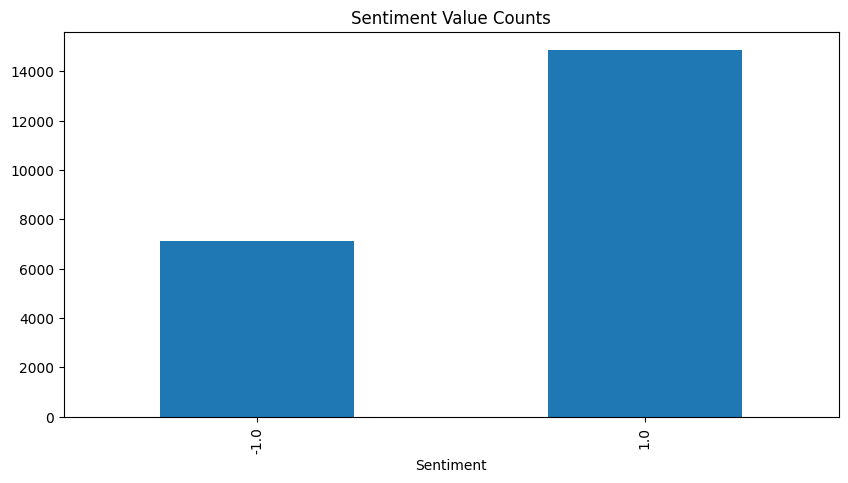

In [12]:
ax = df["Sentiment"].value_counts().sort_index().plot(kind="bar", title="Sentiment Value Counts", figsize=(10,5))
plt.show()

In [13]:
from tqdm import tqdm

score_dic = {}
for idx, row in tqdm(df.iterrows(), total=len(df)):
    text = row["News_Title"]
    row_id = row["id"]
    score_dic[row_id] = roberta_text_encoder(text)

100%|████████████████████████████████████████████████████████████████████████████| 21968/21968 [18:36<00:00, 19.67it/s]


In [16]:
roberta_s_df = pd.DataFrame(score_dic).T
roberta_s_df  = roberta_s_df.reset_index().rename(columns={"index":"id"})
roberta_s_df  = roberta_s_df.merge(df, how="left")

In [18]:
roberta_s_df['roberta_pred'] = roberta_s_df.apply(
    lambda x: 1 if x['positive'] > x['negative'] else -1, axis=1
)

In [19]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(accuracy_score(roberta_s_df['Sentiment'], roberta_s_df['roberta_pred']))
print(classification_report(roberta_s_df['Sentiment'], roberta_s_df['roberta_pred']))

0.8262927895120175
              precision    recall  f1-score   support

        -1.0       0.70      0.82      0.75      7112
         1.0       0.91      0.83      0.87     14856

    accuracy                           0.83     21968
   macro avg       0.80      0.82      0.81     21968
weighted avg       0.84      0.83      0.83     21968



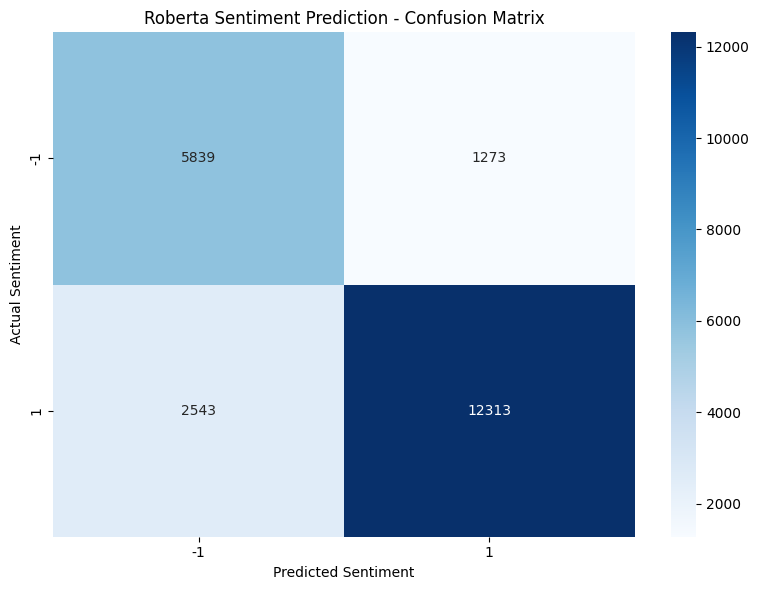

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(roberta_s_df['Sentiment'], roberta_s_df['roberta_pred'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[-1, 1], yticklabels=[-1, 1])
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title("Roberta Sentiment Prediction - Confusion Matrix")
plt.tight_layout()
plt.savefig('roberta_confusion_matrix.png', dpi=150)
plt.show()